# Mass-spring-damper

A mass point on a spring-damper, pushed by a constant force: the shortest model of Exudyn, solved in time and compared
with the exact solution. Every cell runs as it is; the outputs below each cell are those of the last run.

In [1]:
import exudyn as exu
from exudyn.utilities import SensorBody, SensorObject
from exudyn.interactive import ShowImage
import exudyn.graphics as graphics
import numpy as np

print('Exudyn version', exu.config.Version())

Exudyn version 1.12.278.dev1


A `SystemContainer` holds the systems; `mbs` (multibody system) is the one we build. Call it `mbs` in every model,
so that code can be copied between models.

In [2]:
SC = exu.SystemContainer()
mbs = SC.AddSystem()

The parameters: mass, stiffness and damping of the spring-damper, the initial displacement and velocity of the
mass, and the force on it, which displaces the mass statically by $x_0 = f/k$.

In [3]:
L = 0.5             #length of the spring, m
mass = 1.6          #kg
spring = 4000       #stiffness of the spring-damper, N/m
damper = 8          #damping, N/(m/s)
u0 = -0.08          #initial displacement, m
v0 = 1              #initial velocity, m/s
f = 80              #force on the mass, N
x0 = f/spring       #static displacement

print('eigenfrequency (rad/s) =', np.sqrt(spring/mass))
print('static displacement (m) =', x0)

eigenfrequency (rad/s) = 50.0
static displacement (m) = 0.02


The mass point, the ground, the spring-damper between them, and the force. Each `Create...` function adds the
nodes, objects and markers an item needs and returns the index of its object.

In [4]:
oMass = mbs.CreateMassPoint(referencePosition=[L,0,0],
                            initialDisplacement=[u0,0,0],
                            initialVelocity=[v0,0,0],
                            mass=mass,
                            graphicsDataList=[graphics.Sphere(radius=0.05, color=graphics.color.red)])
oGround = mbs.CreateGround(graphicsDataList=[graphics.Brick(centerPoint=[0,0,0], size=[0.02,0.2,0.2],
                                                            color=graphics.color.grey)])

#the reference length is the distance of the two points in the reference configuration, L
oSD = mbs.CreateSpringDamper(bodyNumbers=[oGround, oMass], stiffness=spring, damping=damper)

lForce = mbs.CreateForce(bodyNumber=oMass, loadVector=[f,0,0])

Sensors record the force in the spring-damper and the displacement of the mass at every stored step; with
`storeInternal=True` they keep the values in memory instead of writing a file.

In [5]:
sForce = mbs.AddSensor(SensorObject(objectNumber=oSD, storeInternal=True,
                                    outputVariableType=exu.OutputVariableType.ForceLocal))
sDisp = mbs.AddSensor(SensorBody(bodyNumber=oMass, storeInternal=True,
                                 outputVariableType=exu.OutputVariableType.Displacement))
mbs.Assemble()
print(mbs)

<systemData: 
  Number of nodes= 1
  Number of objects = 3
  Number of markers = 3
  Number of loads = 1
  Number of sensors = 2
  Number of ODE2 coordinates = 3
  Number of ODE1 coordinates = 0
  Number of AE coordinates   = 0
  Number of data coordinates   = 0

For details see mbs.systemData, mbs.sys and mbs.variables
>


The model as the renderer draws it - in a notebook as an image of the raytracer, without a window. A script
would call `SC.renderer.Start()` instead and see the motion.

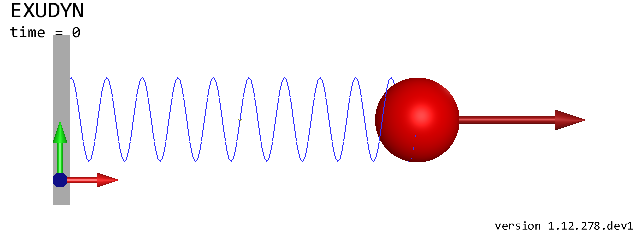

In [6]:
SC.visualizationSettings.connectors.springNumberOfWindings = 10
SC.visualizationSettings.loads.drawSimplified = False
SC.visualizationSettings.general.showSolverInformation = False
image = ShowImage(SC, size=[640,240])

Solve in time: 1000 steps of 1 ms, with the implicit trapezoidal rule.

In [7]:
tEnd = 1     #end time, s
h = 0.001    #step size, s

simulationSettings = exu.SimulationSettings()
simulationSettings.timeIntegration.numberOfSteps = int(tEnd/h)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.solution.file.writePeriod = 5e-3
simulationSettings.solution.sensors.writePeriod = 5e-3

mbs.SolveDynamic(simulationSettings, solverType=exu.DynamicSolverType.TrapezoidalIndex2)

u = mbs.GetObjectOutputBody(oMass, exu.OutputVariableType.Displacement)
print('displacement at t=1 s:', u)

displacement at t=1 s: [0.01183493 0.         0.        ]


The exact solution of the damped oscillator,
$x(t) = e^{-\omega_0 D t}\left(C_1 \cos(\omega t) + C_2 \sin(\omega t)\right) + x_0$
with $\omega_0 = \sqrt{k/m}$, $D = d/(2\sqrt{k m})$ and $\omega = \omega_0\sqrt{1-D^2}$, and the numerical one
in one plot; `PlotSensor` takes a sensor or a matrix whose first column is the time.

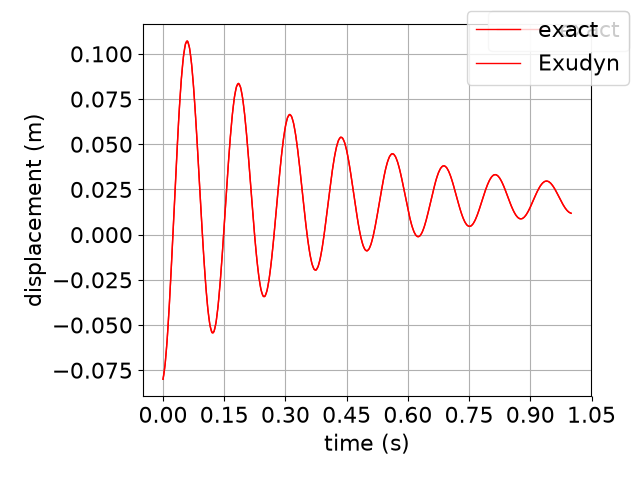

In [8]:
omega0 = np.sqrt(spring/mass)
D = damper/(2*np.sqrt(spring*mass))
omega = omega0*np.sqrt(1-D**2)
C1 = u0 - x0
C2 = (v0 + omega0*D*C1)/omega

t = np.linspace(0, tEnd, 1001)
exact = np.column_stack((t, np.exp(-omega0*D*t)*(C1*np.cos(omega*t) + C2*np.sin(omega*t)) + x0))

mbs.PlotSensor(sensorNumbers=[exact], components=[0], labels=['exact'], yLabel='displacement (m)', closeAll=True)
mbs.PlotSensor(sensorNumbers=[sDisp], components=[0], labels=['Exudyn'], yLabel='displacement (m)', newFigure=False)

The force in the spring-damper, in kN:

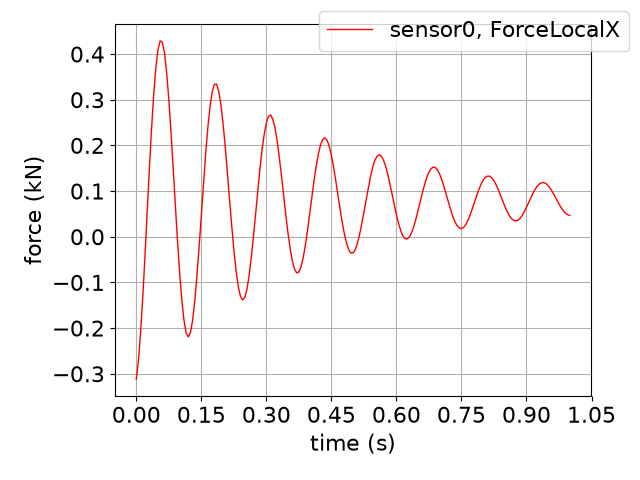

In [9]:
mbs.PlotSensor(sensorNumbers=sForce, components=0, factors=[1e-3], yLabel='force (kN)')

In a script, `mbs.SolutionViewer()` shows the stored motion forward and backward in the render window.